<div align="center">

<img src="https://upload.wikimedia.org/wikipedia/commons/8/83/Steam_icon_logo.svg" width="120">

# Steam Games EDA & Visualization Project

### Exploratory Data Analysis of Steam Marketplace Data

# **BY:** Ansh Bansal

</div>

---

## Objective

Analyze Steam games data to understand pricing, reviews, genres, developers, publishers, and platform trends.

# Dataset Overview

This dataset contains information about games available on the Steam platform. It includes game details, pricing information, review metrics, hardware requirements, genres, developers, publishers, and user-generated tags.

The objective of this analysis is to explore trends in the Steam gaming market, understand player preferences, identify popular genres and publishers, and uncover business insights that can help game developers and publishers make better decisions.

## Dataset Columns

| Column            | Description                               |
| ----------------- | ----------------------------------------- |
| Appid             | Unique Steam application ID for each game |
| Name              | Name of the game                          |
| Type              | Type of Steam product (Game, DLC, etc.)   |
| ReleaseDate       | Official release date of the game         |
| Genres            | Genres associated with the game           |
| Developers        | Developer(s) of the game                  |
| Publishers        | Publisher(s) of the game                  |
| Description       | Store description of the game             |
| price             | Current price of the game                 |
| Thumbnail         | URL of the game's thumbnail image         |
| Tags              | User-generated tags describing the game   |
| ReviewScore       | Overall review score category             |
| PositiveReview    | Number of positive reviews                |
| NegativeReview    | Number of negative reviews                |
| OsRequirement     | Operating system requirements             |
| MemoryRequirement | RAM requirement                           |
| CpuRequirement    | Processor requirement                     |
| Rank              | Steam ranking or popularity indicator     |



# Notebook EDA steps (notebook order)

1. Import libraries: pandas, numpy, matplotlib, seaborn, re
2. Load dataset from SteamGames.csv into `df`
3. Initial peek: `df.head()`, `df.tail()`, `df.sample()`
4. Structure checks: `df.shape`, `df.columns`, `df.info()`, `df.describe()`
5. Missing & duplicates: `df.isnull().sum()`, `df.duplicated().sum()`
6. Drop `Thumbnail` column
7. Clean `price` and parse `ReleaseDate` into datetime
8. Drop rows missing `ReleaseDate`
9. Filter `Type` to only `game` and `dlc`
10. Drop rows missing `Genres`
11. Fill missing metadata: `Developers`, `Publishers`, `Description`, `Tags`
12. Normalize OS requirements: dictionary replacements + normalization function
13. Fill `MemoryRequirement` and `CpuRequirement` with 'Not Specified'
14. Feature engineering: `TotalReviews`, `ReleaseYear`, `ReleaseMonth`, `IsFree`,`Pos_Ratio`,`ReleaseDay`
15. Export to CSV

These steps are generated directly from the notebook cells and their execution order.

### Import Required Libraries
In this step, the necessary Python libraries for data analysis, visualization, and data cleaning are imported.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

### Load the Dataset
The Steam Games dataset is loaded into a pandas DataFrame so it can be explored and analyzed.

In [2]:
df = pd.read_csv("SteamGames.csv")

### Preview the First Rows
Take a quick look at the first few records to understand the structure of the dataset.

In [3]:
df.head()

,Appid,Name,Type,ReleaseDate,Genres,Developers,Publishers,Description,price,Thumbnail,Tags,ReviewScore,PositiveReview,NegativeReview,OsRequirement,MemoryRequirement,CpuRequirement,Rank
0,3764200,Resident Evil Requiem,game,"Feb 26, 2026","Action,Adventure","CAPCOM Co., Ltd.","CAPCOM Co., Ltd.",Resident Evil Requiem Deluxe Edition Resident ...,69.99$,https://shared.akamai.steamstatic.com/store_it...,NaN,9,23715,793,NaN,NaN,NaN,1
1,730,Counter-Strike 2,game,"Aug 21, 2012","Action,Free To Play",Valve,Valve,"For over two decades, Counter-Strike has offer...",0$,https://shared.akamai.steamstatic.com/store_it...,"FPS,Shooter,Multiplayer,Competitive,Action,Tea...",8,1214897,202393,Windows® 10,8 GB RAM,4 hardware CPU threads - Intel® Core™ i5 750 o...,2
2,1808500,ARC Raiders,game,"Oct 30, 2025",Action,Embark Studios,Embark Studios,ARC Raiders Deluxe Edition ARC Raiders Deluxe ...,39.99$,https://shared.akamai.steamstatic.com/store_it...,"Extraction Shooter,Multiplayer,PvP,PvE,Third-P...",8,149531,23194,Windows 10 or later 64-bit (latest update),12 GB RAM,Intel Core i5-6600K or AMD Ryzen R5 1600 proce...,3
3,359550,Tom Clancy's Rainbow Six Siege,game,"Dec 1, 2015","Action,Free To Play",Ubisoft Montreal,Ubisoft,Season 11 Year 1 Overview Year 11 Roadmap Free...,0$,https://shared.akamai.steamstatic.com/store_it...,NaN,8,522886,106839,NaN,NaN,NaN,4
4,1172470,Apex Legends™,game,"Nov 4, 2020","Action,Adventure,Free To Play",Respawn,Electronic Arts,Apex Legends: Breach About the Game Conquer wi...,0$,https://shared.akamai.steamstatic.com/store_it...,"Free to Play,Multiplayer,Battle Royale,FPS,Sho...",6,820,216,64-bit Windows 10,6 GB RAM,"AMD FX 4350 or Equivalent, Intel Core i3 6300 ...",5


### Preview the Last Rows
Inspect the last few records to ensure the dataset was loaded correctly.

In [4]:
df.tail()

,Appid,Name,Type,ReleaseDate,Genres,Developers,Publishers,Description,price,Thumbnail,Tags,ReviewScore,PositiveReview,NegativeReview,OsRequirement,MemoryRequirement,CpuRequirement,Rank
29926,843170,ILLUSION,game,"May 9, 2018","Adventure,Indie",LunaRolexLer,LunaRolexLer,Guilt Is The Feeling That Makes You Human. Thi...,1.99$,https://shared.akamai.steamstatic.com/store_it...,"Indie,Adventure,RPGMaker,Female Protagonist,Si...",7,39,2,Windows XP/Vista/7/8/10,100 MB RAM,NaN,16715
29927,1308250,Knight Bewitched 2,game,"Aug 10, 2020","Adventure,Indie,RPG",Joshua Keith,Joshua Keith,Knight Bewitched 2 is a jRPG featuring the sto...,4.99$,https://shared.akamai.steamstatic.com/store_it...,"LGBTQ+,Female Protagonist,JRPG,Indie,Story Ric...",7,24,0,7 and above,2 GB RAM,2.2GHz dual-core,16716
29928,1729610,Redmatch 2 - Fashionable Attire Bundle,dlc,"Aug 17, 2021","Action,Free To Play,Indie",Rugbug Redfern,Rugbug Redfern,Bundle Content: Top Hat (Hat) Halo (Hat) Prope...,4.99$,https://shared.akamai.steamstatic.com/store_it...,"Action,Free to Play,Indie",0,7,1,Windows 7 or later,4 GB RAM,2.6 GHz Dual Core or similar,16717
29929,3956320,Inotia 4,game,"Dec 7, 2025","RPG,Free To Play",Com2uS,Com2uS,The grand adventure across the continent of In...,0$,https://shared.akamai.steamstatic.com/store_it...,"Singleplayer,RPG,2D,Fantasy,Pixel Graphics,Sto...",0,0,0,Windows 10 (64bit),8 GB RAM,Ryzen 2200g / Intel i3 8100,16718
29930,791180,1 Screen Platformer,game,"Mar 6, 2019","Action,Adventure,Indie","Return To Adventure Mountain, LLC","Return To Adventure Mountain, LLC",Get ready because the sequel is coming soon: T...,2.99$,https://shared.akamai.steamstatic.com/store_it...,"Precision Platformer,Difficult,2D Platformer,S...",8,147,22,Windows 7 or Later,1 GB RAM,2 GHz,16719


### Random Sample Inspection
View random rows from the dataset to get an unbiased understanding of the data.

In [5]:
df.sample(10)

,Appid,Name,Type,ReleaseDate,Genres,Developers,Publishers,Description,price,Thumbnail,Tags,ReviewScore,PositiveReview,NegativeReview,OsRequirement,MemoryRequirement,CpuRequirement,Rank
15736,408730,The Escapists - Duct Tapes are Forever,dlc,"Nov 3, 2015","Action,Adventure,Indie,Simulation,Strategy",Mouldy Toof Studios,Team17 Digital Ltd,‘Duct Tapes Are Forever’ is all new downloadab...,3.99$,https://shared.akamai.steamstatic.com/store_it...,"Adventure,Indie,Simulation,Strategy,Action",7,18,4,Windows XP,2 GB RAM,Dual Core CPU 2.4 gHz,2525
20264,1795430,Sakura Succubus 5,game,"Apr 4, 2022",Simulation,Winged Cloud,Winged Cloud,In this visual novel Ogasawara Hiroki was a th...,9.99$,https://shared.akamai.steamstatic.com/store_it...,"Simulation,Anime,Romance,Visual Novel,2D,Conve...",7,42,3,Windows 7+,NaN,1.2 GHz Pentium 4,7053
4773,2014550,Voidwrought,game,"Oct 24, 2024","Action,Adventure,Indie",Powersnake,Kwalee,Join Our Discord! About the Game The coming of...,6.79$,https://shared.akamai.steamstatic.com/store_it...,"Metroidvania,Dark,Lore-Rich,2D Platformer,Expl...",6,321,82,Windows 10,8 GB RAM,Intel Core i5-4670 / AMD Ryzen 3 120,4774
5301,4030770,WARNO - Nemesis #4 - Capital Defence,dlc,"Nov 13, 2025","Action,Indie,Simulation,Strategy",Eugen Systems,NaN,Nemesis - Capital Defence is the fourth Nemesi...,4.99$,https://shared.akamai.steamstatic.com/store_it...,"Strategy,Action,Indie,Simulation",6,17,7,64-bit Windows 11 / 10 / 8.1 / 7 with Service ...,4 GB RAM,"2 cores Intel (Intel Celeron G6900, G4920 or i...",5302
25943,3651020,Forest Ranger Services: Episode 2,game,"Sep 10, 2025","Adventure,Casual,Indie",GuardHouse,GuardHouse,The Forest Ranger Services series are based on...,3.99$,https://shared.akamai.steamstatic.com/store_it...,"Casual,Horror,Adventure,Psychological Horror,W...",7,26,3,Windows 10 64 bit,8 GB RAM,Intel Core i3-10100F,12732
17446,946770,Scheming Through The Zombie Apocalypse Ep2: Caged,game,"Apr 16, 2024","Adventure,Indie",Entertainment Forge,GrabTheGames,"Continue the adventure with Hank and Larry, tw...",0.83$,https://shared.akamai.steamstatic.com/store_it...,"Story Rich,Choices Matter,Post-apocalyptic,Dar...",8,53,6,Windows Vista or greater,2 GB RAM,2 Ghz,4235
17885,1088770,Car Mechanic Simulator VR,game,"Jun 8, 2021","Racing,Simulation","GameFormatic S.A.,Red Dot Games",PlayWay S.A.,"CAR MECHANIC SIMULATOR VR Repair, customizatio...",19.99$,https://shared.akamai.steamstatic.com/store_it...,"Automobile Sim,Simulation,VR,Racing,Driving,Re...",5,124,83,Windows 10,16 GB RAM,Intel Core i7 / AMD Ryzen 7,4674
1221,1065310,Evil West,game,"Nov 21, 2022","Action,Adventure,RPG",Flying Wild Hog,Focus Entertainment,Evil never sleeps… but it bleeds. A dark menac...,9.99$,https://shared.akamai.steamstatic.com/store_it...,NaN,6,3417,1110,NaN,NaN,NaN,1222
8864,2419622,Saints Row - A Song of Ice and Dust,dlc,"Aug 24, 2023",Action,Volition,Deep Silver,When a crippling ambush decimates the Dustland...,7.99$,https://shared.akamai.steamstatic.com/store_it...,NaN,7,30,6,NaN,NaN,NaN,8865
13417,2287980,Country Bumpkin Yutaka,game,"May 19, 2023","Indie,RPG",Ota Guchi Field,Kagura Games,Yutaka just spent a good chunk of her summer i...,10.49$,https://shared.akamai.steamstatic.com/store_it...,"Sexual Content,Hentai,Nudity,RPG,Mature,Anime,...",6,26,10,Windows® 7/8/8.1/10,4 GB RAM,Intel Core2 Duo or better,206


### Check Dataset Shape
Identify how many rows and columns are present in the dataset.

In [6]:
df.shape

(29931, 18)

### Explore Column Names
Review all available features and variables in the dataset.

In [7]:
df.columns

Index(['Appid', 'Name', 'Type', 'ReleaseDate', 'Genres', 'Developers',
       'Publishers', 'Description', 'price', 'Thumbnail', 'Tags',
       'ReviewScore', 'PositiveReview', 'NegativeReview', 'OsRequirement',
       'MemoryRequirement', 'CpuRequirement', 'Rank'],
      dtype='str')

### Inspect Data Types
Understand the data types and non-null counts for each column.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29931 entries, 0 to 29930
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Appid              29931 non-null  int64
 1   Name               29931 non-null  str  
 2   Type               29931 non-null  str  
 3   ReleaseDate        29917 non-null  str  
 4   Genres             29518 non-null  str  
 5   Developers         29905 non-null  str  
 6   Publishers         28886 non-null  str  
 7   Description        29879 non-null  str  
 8   price              29931 non-null  str  
 9   Thumbnail          29931 non-null  str  
 10  Tags               28317 non-null  str  
 11  ReviewScore        29931 non-null  int64
 12  PositiveReview     29931 non-null  int64
 13  NegativeReview     29931 non-null  int64
 14  OsRequirement      26994 non-null  str  
 15  MemoryRequirement  25947 non-null  str  
 16  CpuRequirement     26072 non-null  str  
 17  Rank               2993

### Generate Statistical Summary
View descriptive statistics for numerical columns.

In [9]:
df.describe()

,Appid,ReviewScore,PositiveReview,NegativeReview,Rank
count,2.993100e+04,29931.000000,2.993100e+04,29931.000000,29931.000000
mean,1.722531e+06,6.237145,1.443837e+03,193.180849,7585.978350
std,1.116414e+06,2.560245,1.368262e+04,2084.565186,4493.478798
min,1.000000e+01,0.000000,0.000000e+00,0.000000,1.000000
25%,7.511550e+05,6.000000,1.700000e+01,2.000000,3742.000000
50%,1.568970e+06,7.000000,5.900000e+01,9.000000,7483.000000
75%,2.587215e+06,8.000000,2.700000e+02,47.000000,11224.500000
max,4.460980e+06,9.000000,1.214897e+06,202393.000000,16719.000000


### Check Missing Values
Identify columns containing missing information.

In [10]:
df.isnull().sum()

Appid                   0
Name                    0
Type                    0
ReleaseDate            14
Genres                413
Developers             26
Publishers           1045
Description            52
price                   0
Thumbnail               0
Tags                 1614
ReviewScore             0
PositiveReview          0
NegativeReview          0
OsRequirement        2937
MemoryRequirement    3984
CpuRequirement       3859
Rank                    0
dtype: int64

### Check for Duplicate Records
Determine whether duplicate rows exist in the dataset.

In [11]:
df.duplicated().sum()

np.int64(0)

### Remove Unnecessary Columns
The Thumbnail column is removed because it does not contribute to the analysis.

In [12]:
df.drop(columns=["Thumbnail"], inplace=True)

### Convert Data Types
Clean and convert important columns such as price and release date into usable formats.

In [13]:
df['price']=df['price'].str.replace('$','').astype(float)
df['ReleaseDate'] = pd.to_datetime(df['ReleaseDate'], errors='coerce')

### Handle Missing Release Dates
Remove records where release date information is unavailable.

In [14]:
df.dropna(subset=['ReleaseDate'], inplace=True)

### Keep Only Relevant Product Types
Retain only Games and DLCs while removing unrelated product categories.

In [15]:
df = df[df["Type"].isin(["game", "dlc"])]

### Handle Missing Genres
Remove records with missing genre information because genre analysis is a key objective.

In [16]:
df.dropna(subset=["Genres"], inplace=True)

### Fill Missing Developer Information
Replace missing developer names with 'Unknown' to preserve records.

In [17]:
df["Developers"] = df["Developers"].fillna("Unknown")

### Fill Missing Publisher Information
Replace missing publisher names with 'Unknown' for consistency.

In [18]:
df["Publishers"] = df["Publishers"].fillna("Unknown")

### Handle Missing Descriptions
Fill missing descriptions with a placeholder value.

In [19]:
df["Description"] = df["Description"].fillna("No Description Available")

### Handle Missing Tags
Replace missing tags with a placeholder category.

In [20]:
df["Tags"] = df["Tags"].fillna("No Tags Available")

### Standardize Operating System Information
Clean and normalize OS requirement values into consistent categories.

In [21]:
os_replacements = {
    '10': 'Windows 10',
    '7': 'Windows 7',
    'Windows 10 or later': 'Windows 10, 11',
    'Windows 10 or newer': 'Windows 10',
    'Windows 10 or higher': 'Windows 10',
    'Windows 10+': 'Windows 10',
    'Windows 10 (64-bit)': 'Windows 10 64-bit',
    'Windows 10 (64bit)': 'Windows 10 64-bit',
    'Windows 10 64bit': 'Windows 10 64-bit',
    'Windows 10 64-Bit': 'Windows 10 64-bit',
    'Windows 10 64 bit': 'Windows 10 64-bit',
    'Windows 10 x64': 'Windows 10 64-bit',
    'Windows 10 64 Bit': 'Windows 10 64-bit',
    'Windows 10 (64-bit)': 'Windows 10 64-bit',
    '64-bit Windows 10': 'Windows 10 64-bit',
    'Windows® 10 Home 64 Bit': 'Windows 10 64-bit',
    'WINDOWS® 10 (64-bit required)': 'Windows 10 64-bit',
    'Windows10': 'Windows 10',
    'Win 10': 'Windows 10',
    'Windows 7 or later': 'Windows 7, 8, 10',
    'Windows 7 or higher': 'Windows 7, 8, 10',
    'Windows 7 or newer': 'Windows 7',
    'Windows 7+': 'Windows 7',
    'Windows 7 SP1+': 'Windows 7',
    'Windows 7 SP1': 'Windows 7',
    'Windows 7 64bit': 'Windows 7 64-bit',
    'Windows 7/8/10': 'Windows 7, 8, 10',
    'Windows 7/8/8.1/10': 'Windows 7, 8, 10',
    'Windows 7 / 8 / 10': 'Windows 7, 8, 10',
    'Windows 7/8/10/11': 'Windows 7, 8, 10, 11',
    'Windows 7/8/10 (64-bit)': 'Windows 7, 8, 10 64-bit',
    'Windows 7/8/10 (64-bit OS required)': 'Windows 7, 8, 10 64-bit',
    'Windows® 7/8/8.1/10': 'Windows 7, 8, 10',
    'Windows 10/11': 'Windows 10, 11',
    'Windows 10 / 11': 'Windows 10, 11',
    'Windows XP/Vista/7/8/10': 'Windows XP, Vista, 7, 8, 10',
    'Windows XP SP2+': 'Windows XP',
    'Windows XP SP3': 'Windows XP',
}

df['OsRequirement'] = df['OsRequirement'].replace(os_replacements)


def normalize_os_requirement(value):
    if pd.isna(value) or str(value).strip() == '':
        return 'Not Specified'

    req = str(value).strip()
    req = req.replace('®', '')
    req = req.replace('（', '(').replace('）', ')')
    req = req.replace('–', '-').replace('—', '-')
    req = req.lower()
    req = re.sub(r'windows\s*xp(?: or later| or newer| or higher| or above)?', 'windows xp or later', req)
    req = re.sub(r'windows\s*7(?: or later| or newer| or higher| or above| and above)?', 'windows 7 or later', req)
    req = re.sub(r'windows\s*10(?: or later| or newer| or higher| or above)?', 'windows 10 or later', req)
    req = re.sub(r'windows\s*11(?: or later| or newer| or higher| or above)?', 'windows 11 or later', req)
    req = re.sub(r'windows\s*8\.1', 'windows 8.1', req)
    req = re.sub(r'win\s*10', 'windows 10', req)
    req = re.sub(r'windows10', 'windows 10', req)
    req = re.sub(r'64\s*bit|64bit|64[- ]bit', '64-bit', req)
    req = req.replace('/', ' ')
    req = re.sub(r'\b(or later|or higher|or newer|or above|and above|must have|requires|required|supporting|supported|recommended|minimum|minimum system requirements|operating system)\b', '', req)
    req = re.sub(r'[^a-z0-9., -]', ' ', req)
    req = re.sub(r'\s+', ' ', req).strip()

    if 'windows xp or later' in req:
        return 'Windows XP, Vista, 7, 8, 10, 11'
    if 'windows 7 or later' in req:
        return 'Windows 7, 8, 8.1, 10, 11'
    if 'windows 10 or later' in req:
        return 'Windows 10, 11'
    if 'windows 11 or later' in req:
        return 'Windows 11'

    versions = []
    for version in ['windows xp', 'windows vista', 'windows 7', 'windows 8.1', 'windows 8', 'windows 10', 'windows 11']:
        if version in req and version.title() not in versions:
            versions.append(version.title())

    if not versions:
        return 'Windows'

    normalized = ', '.join(versions)
    if '64-bit' in req and len(versions) == 1:
        normalized = f'{normalized} 64-bit'

    return normalized

df['OsRequirement'] = df['OsRequirement'].apply(normalize_os_requirement)

### Handle Missing Memory Requirements
Fill missing memory requirement values with 'Not Specified'.

In [22]:
df['MemoryRequirement'] = df['MemoryRequirement'].fillna('Not Specified')

### Handle Missing CPU Requirements
Fill missing CPU requirement values with 'Not Specified'.

In [23]:
df["CpuRequirement"] = df["CpuRequirement"].fillna("Not Specified")

### Feature Engineering
Create new features to support deeper analysis.

In [24]:
df["TotalReviews"] =(df["PositiveReview"] + df["NegativeReview"])

df["ReleaseYear"] =df["ReleaseDate"].dt.year.astype('Int16')

df["ReleaseMonth"] =df["ReleaseDate"].dt.month_name()

df['IsFree'] = df['price'] == 0

df['Pos_Ratio'] = np.where(df['TotalReviews'] > 0, df['PositiveReview'] / df['TotalReviews'], np.nan)

df['ReleaseDay'] = df['ReleaseDate'].dt.day_name()

### Export the Cleaned Dataset
Save the cleaned dataset for future analysis and visualization.

In [25]:
df.to_csv("Cleaned_SteamGames.csv", index=False)

># ***EXPLORATORY DATA ANALYSIS***

In [26]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 7) 
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

# What is the standard distribution of game prices on Steam?

>## Most of the market is crowded with cheap titles under $10 If a developer wants to charge more than $20, they need either strong marketing or a well-known franchise, because that price range is a smaller, tougher premium tier.

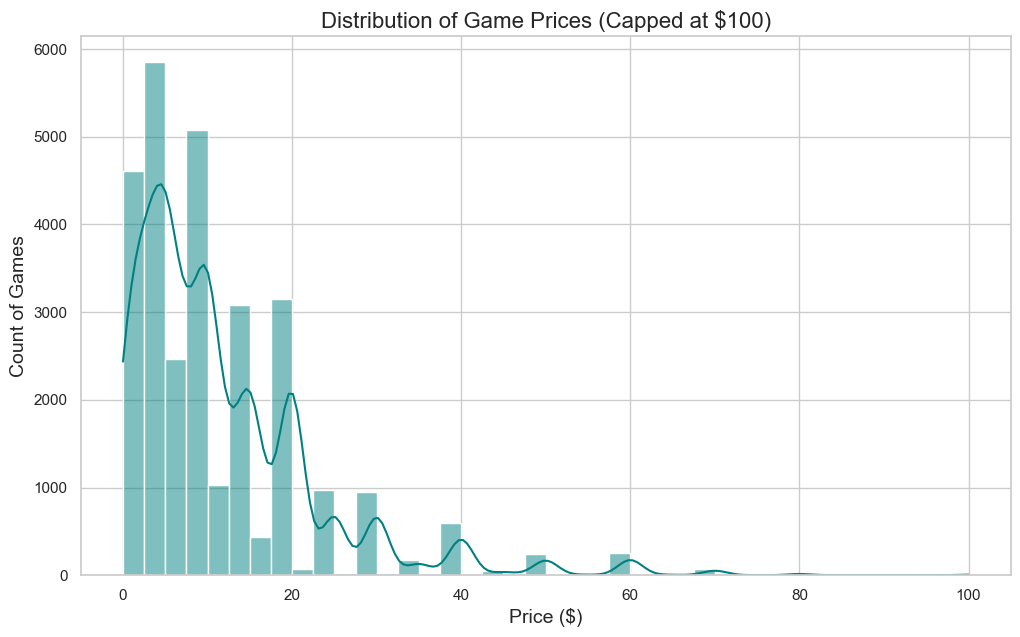

In [27]:
plt.figure()
sns.histplot(df[df['price'] <= 100]['price'],bins=40, kde=True, color='teal')
plt.title('Distribution of Game Prices (Capped at $100)')
plt.xlabel('Price ($)')
plt.ylabel('Count of Games')
plt.show()

# What proportion of the Steam market is entirely Free-to-Play?


>## Free-to-Play (F2P) is a massive segment. About 15-20% of games are free, relying entirely on microtransactions, battle passes, or DLCs for revenue.

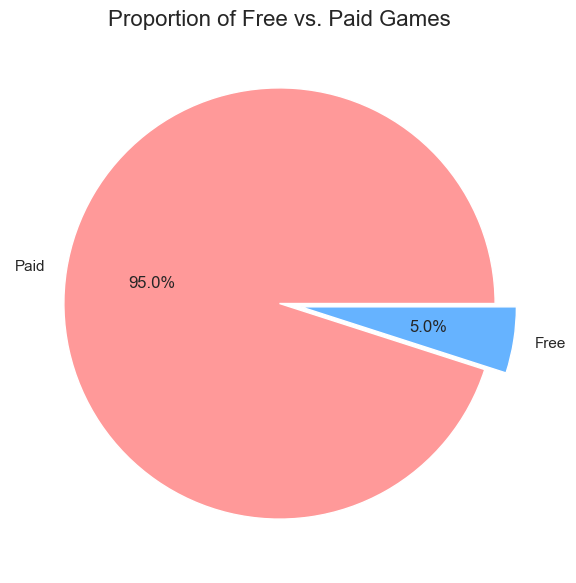

In [28]:
plt.figure()
free_counts = df['IsFree'].value_counts()
plt.pie(free_counts.values, labels=['Paid', 'Free'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], explode=[0, 0.1])
plt.title('Proportion of Free vs. Paid Games')
plt.show()

# Does making a game more expensive lead to harsher reviews?

>## Yes. As the price increases toward the $60 AAA tier, the variance in positive reviews widens. Players are much more unforgiving of bugs or short playtimes when they pay premium prices.

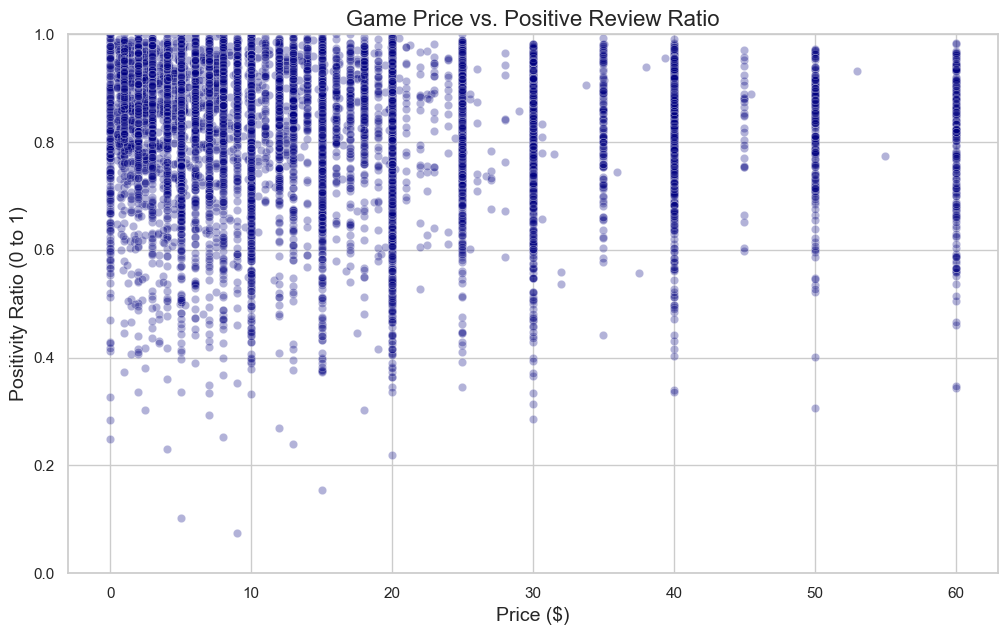

In [29]:
plt.figure()
sns.scatterplot(data=df[(df['price'] <= 60) & (df['TotalReviews'] > 100)], x='price', y='Pos_Ratio', alpha=0.3, color='navy')
plt.title('Game Price vs. Positive Review Ratio')
plt.xlabel('Price ($)')
plt.ylabel('Positivity Ratio (0 to 1)')
plt.ylim(0, 1)
plt.show()

# How is player attention (Total Reviews) distributed across games?

>## Steam is a "Winner-Takes-All" economy. A tiny fraction of viral games capture 90% of all player reviews and attention, while the vast majority of games are virtually ignored.

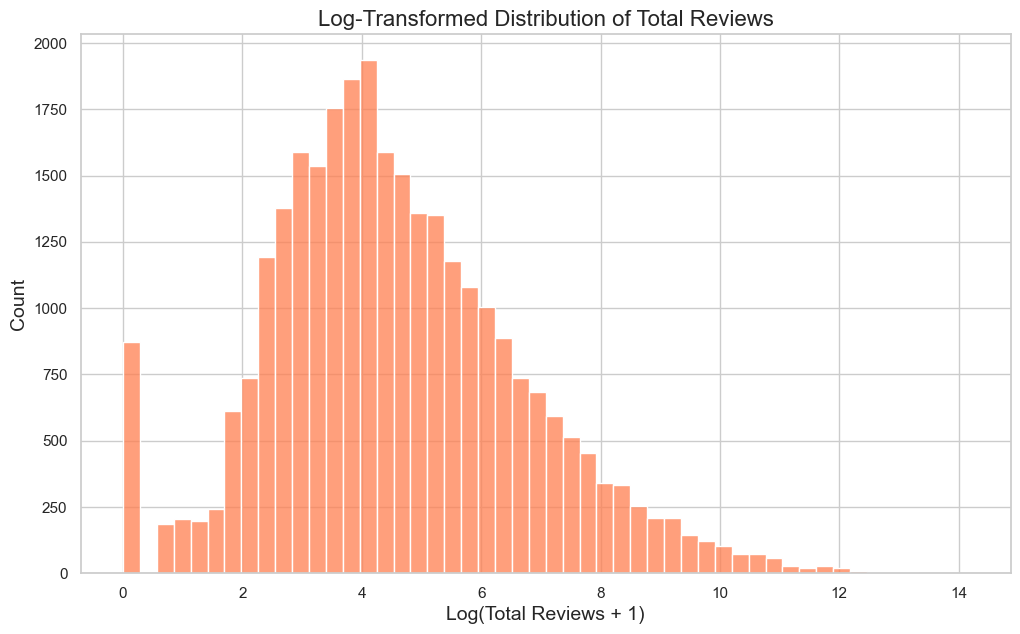

In [30]:
plt.figure()
sns.histplot(np.log1p(df['TotalReviews']), bins=50, color='coral',)
plt.title('Log-Transformed Distribution of Total Reviews')
plt.xlabel('Log(Total Reviews + 1)')
plt.show()

# # Revenue Proxy Across Different Price Tiers?

>## The majority of the estimated revenue is generated by games priced between $30 and $60. While premium-priced games exist, they contribute a smaller share due to lower volume and engagement.

### Since actual sales data is not available in the dataset, a revenue proxy is created by multiplying the game price by its total number of reviews. Although this is not actual revenue, it provides an approximate measure of a game's commercial impact.

#### Games are then grouped into different price categories to analyze which pricing tier contributes the most to overall engagement-driven revenue.

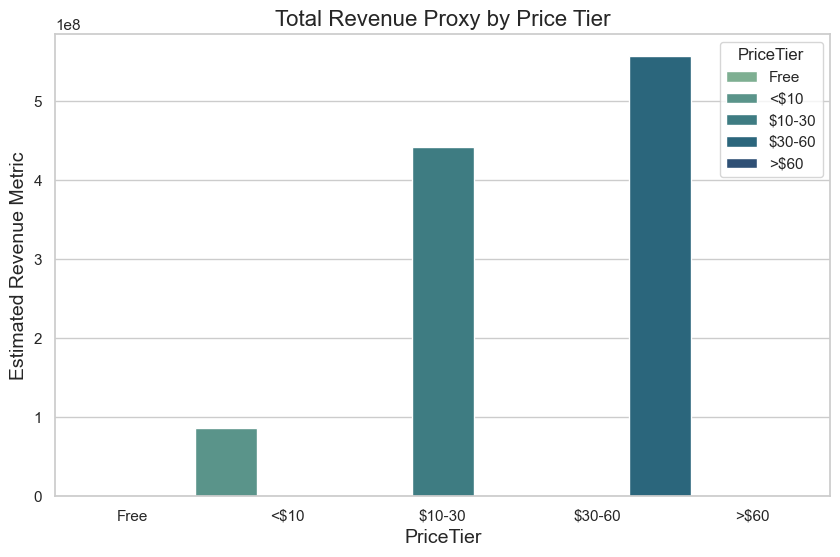

In [31]:
df['Rev_Proxy'] = df['price'] * df['TotalReviews']
bins = [-1, 0, 10, 30, 60, 1000]
labels = ['Free', '<$10', '$10-30', '$30-60', '>$60']
df['PriceTier'] = pd.cut(df['price'], bins=bins, labels=labels)
plt.figure(figsize=(10,6))
sns.barplot(data=df,x='PriceTier',y='Rev_Proxy',estimator=np.sum,palette='crest',hue='PriceTier',errorbar=None,width=2,legend=True)
plt.title('Total Revenue Proxy by Price Tier')
plt.ylabel('Estimated Revenue Metric')
plt.show()

# Do Free games generally get better or worse reviews than Paid games?

>## Paid games usually score better in reviews. Free games, on the other hand, often get hit with review bombing since anyone can jump in and just as easily leave a negative rating without any cost or commitment.

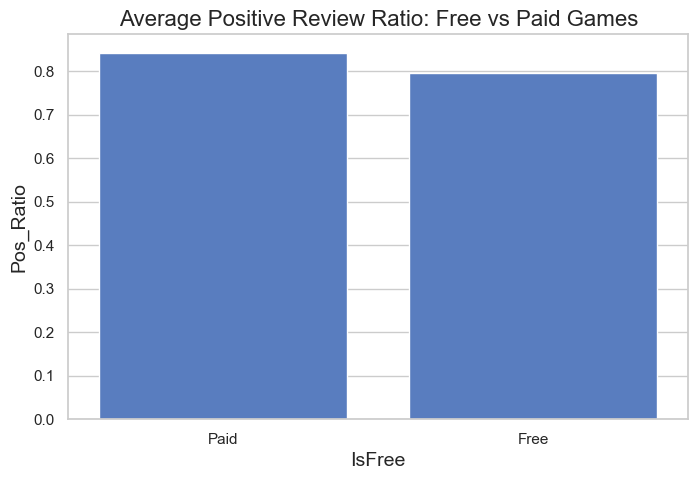

In [32]:
plt.figure(figsize=(8,5))
sns.barplot(data=df[df['TotalReviews'] > 50],x='IsFree',y='Pos_Ratio',errorbar=None)
plt.title('Average Positive Review Ratio: Free vs Paid Games')
plt.xticks([0,1], ['Paid', 'Free'])
plt.show()

# Has the volume of game releases increased over time?

>## The market exploded after 2014 when Steam eased publishing restrictions. The market is now hyper-saturated, meaning marketing is more important than ever for a new release.

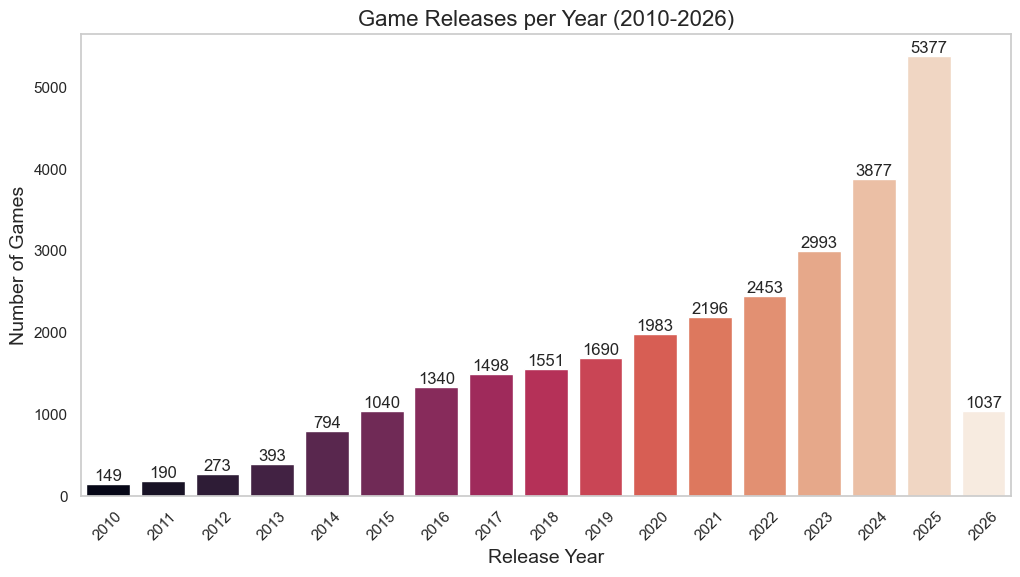

In [33]:
plt.figure(figsize=(12,6))
ax = sns.countplot(data=df[df['ReleaseYear'] >= 2010],x='ReleaseYear',hue='ReleaseYear',palette='rocket',legend=False)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Game Releases per Year (2010-2026)')
plt.grid(False)
plt.xlabel('Release Year')
plt.ylabel('Number of Games')
plt.xticks(rotation=45)
plt.show()

# Have average game prices gone up or down over the last decade?

>## The average price of Steam games has generally increased over time. While there are a few temporary declines, the long-term trend shows a gradual rise from around $10 in 2010 to over $12 in recent years.

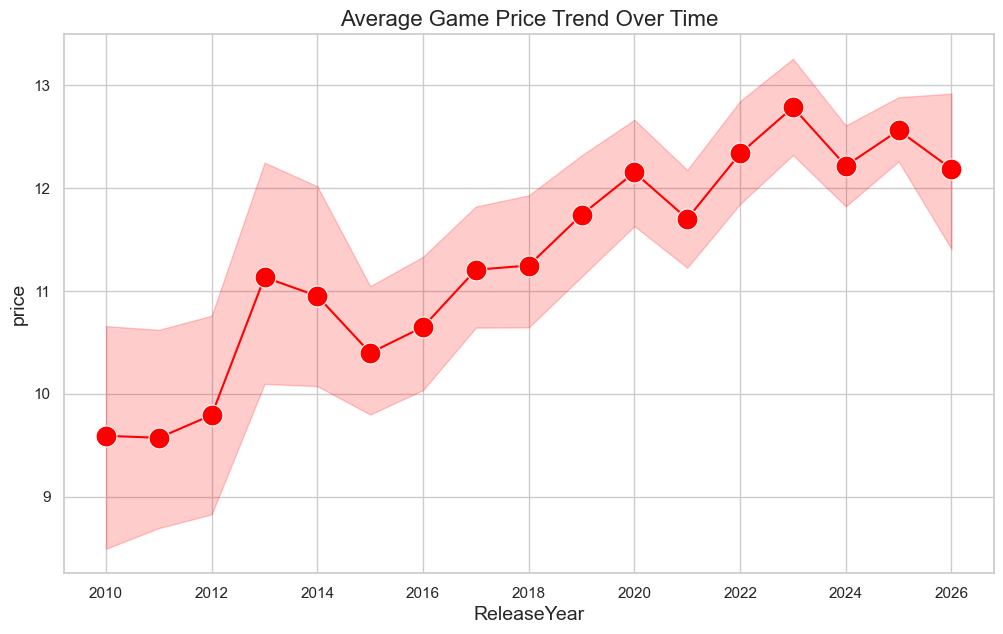

In [34]:
plt.figure()
sns.lineplot(data=df[df['ReleaseYear'] >= 2010], x='ReleaseYear', y='price', color='red', marker='o',markersize=15)
plt.title('Average Game Price Trend Over Time')
plt.show()

# How has the average number of positive reviews changed over time?

>## In general, newer releases tend to rack up more positive reviews, even though some years show ups and downs. This points to the fact that fresh titles usually get more attention and engagement from players on Steam.

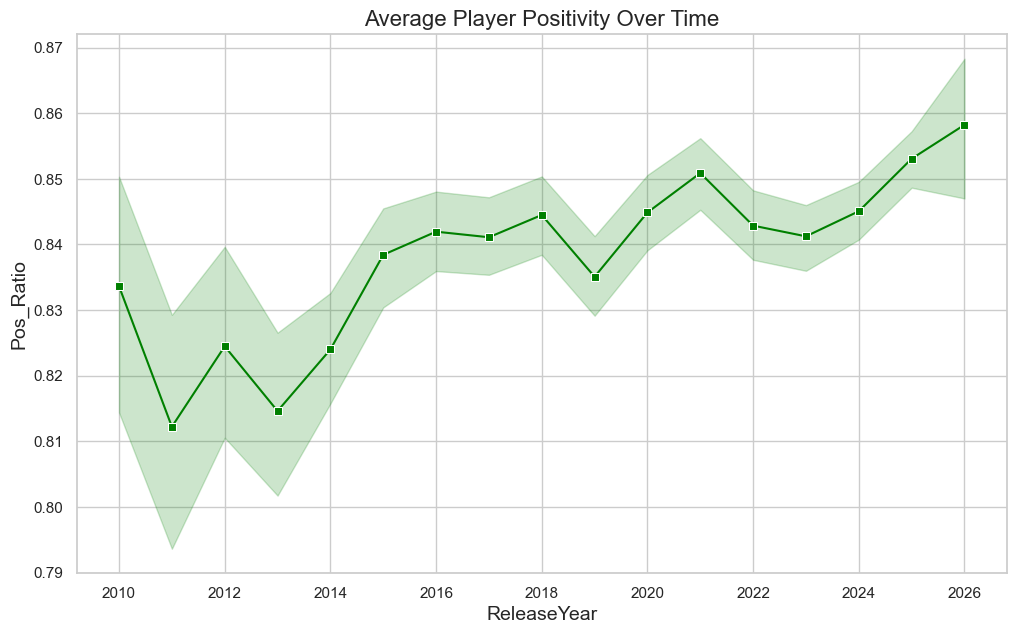

In [35]:
plt.figure()
sns.lineplot(data=df[df['ReleaseYear'] >= 2010], x='ReleaseYear', y='Pos_Ratio', color='green', marker='s')
plt.title('Average Player Positivity Over Time')
plt.show()

# Which month is the most competitive for releasing a game?

>## October and November are highly congested as developers rush to launch before the Steam Winter Sale and Christmas. Releasing in Q1 or Q2 might offer better visibility for smaller studios.

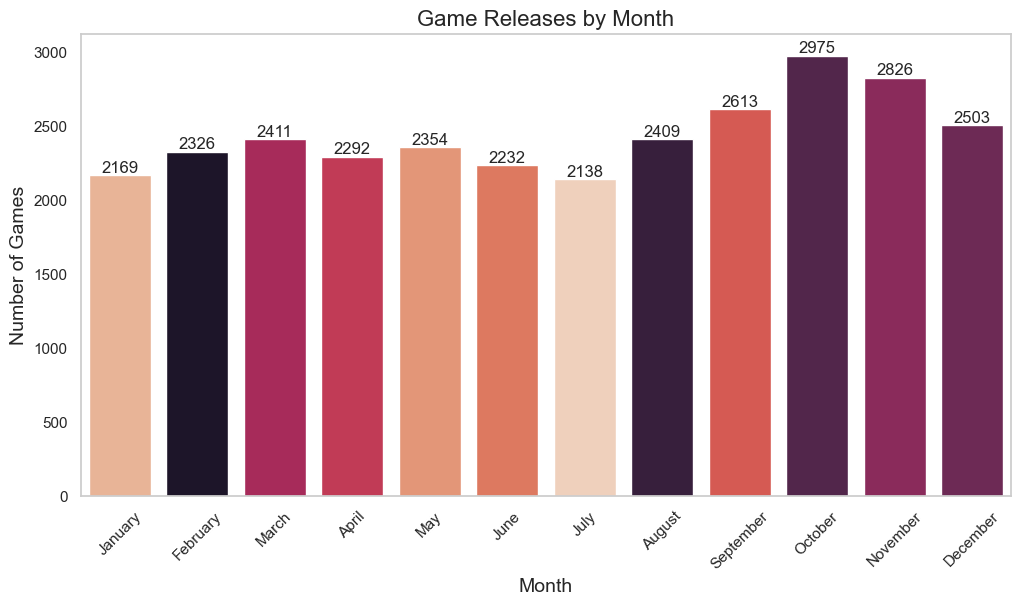

In [36]:
plt.figure(figsize=(12,6))
month_order=['January','February','March','April','May','June','July','August','September','October','November','December']
ax=sns.countplot(data=df,x='ReleaseMonth',order=month_order,hue='ReleaseMonth',palette='rocket',legend=False)
for container in ax.containers: ax.bar_label(container)
plt.title('Game Releases by Month')
plt.grid(False)
plt.xlabel('Month')
plt.ylabel('Number of Games')
plt.xticks(rotation=45)
plt.show()

# What day of the week do developers prefer to launch games?

>## Tuesday and Thursday dominate, as developers avoid weekends to make sure press outlets and Steam’s algorithm catch their launch during standard business hours.

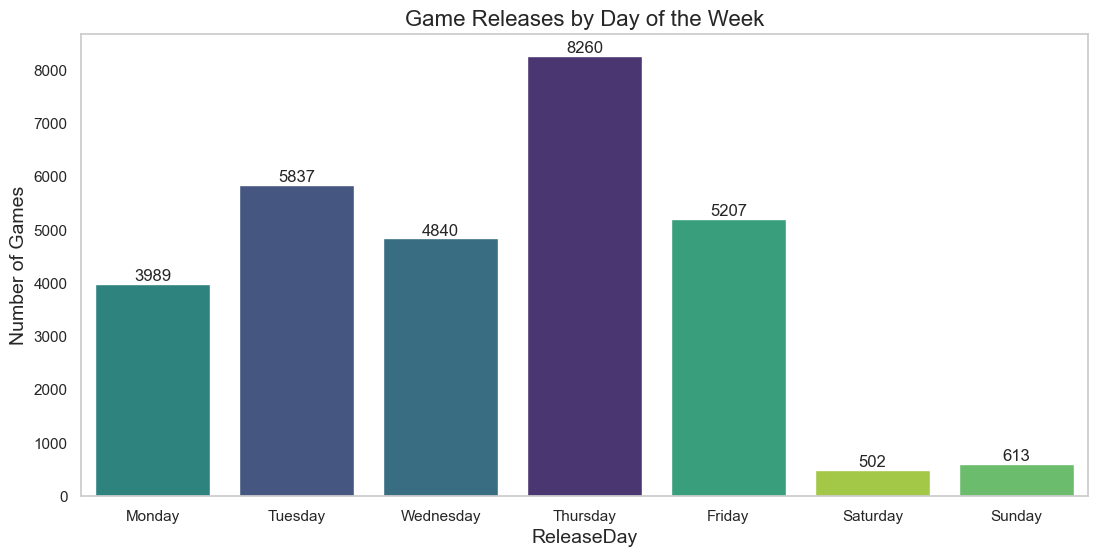

In [37]:
plt.figure(figsize=(13,6))
day_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
ax=sns.countplot(data=df,x='ReleaseDay',order=day_order,hue='ReleaseDay',palette='viridis',legend=False)
for c in ax.containers:ax.bar_label(c)
plt.title('Game Releases by Day of the Week')
plt.grid(False)
plt.ylabel('Number of Games')
plt.show()

# Is the Free-to-Play model growing over time?

>## The sheer volume of Free games entering the market has grown exponentially, confirming F2P as a dominant, permanent business model in modern gaming

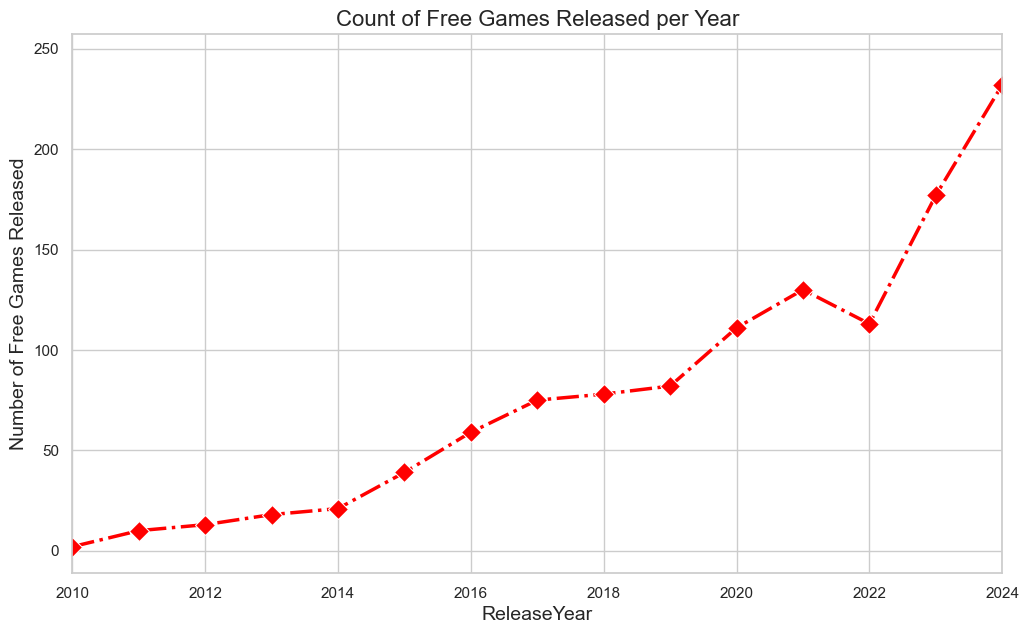

In [38]:
plt.figure()
free_trend = df[df['IsFree'] == True].groupby('ReleaseYear').size()
sns.lineplot(x=free_trend.index, y=free_trend.values, color='red', linewidth=2.5,linestyle='-.', marker='D', markersize=10)
plt.title('Count of Free Games Released per Year')
plt.ylabel('Number of Free Games Released')
plt.xlim(2010, 2024)
plt.show()

# What are the most saturated genres on Steam?

>## "Action", "Indie", and "Adventure" are the most crowded genres. Building a game here requires a highly unique hook to stand out from the noise.

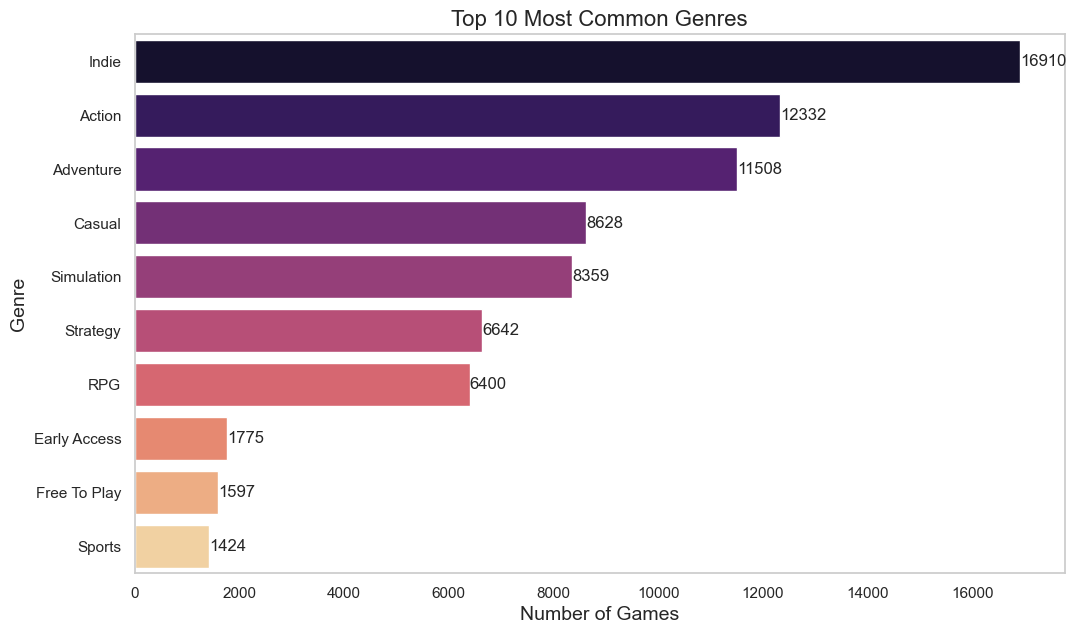

In [39]:
plt.figure(figsize=(12,7))
top_genres=df['Genres'].dropna().str.split(',').explode().value_counts().head(10)
ax=sns.barplot(y=top_genres.index,x=top_genres.values,hue=top_genres.index,palette='magma',legend=False)
for c in ax.containers:ax.bar_label(c)
plt.title('Top 10 Most Common Genres')
plt.xlabel('Number of Games')
plt.ylabel('Genre')
plt.grid(False)
plt.show()

# What user tags are applied most frequently?

>## "Singleplayer" dominates. Despite the massive media focus on esports and multiplayer, the vast majority of the catalog caters to solo experiences.

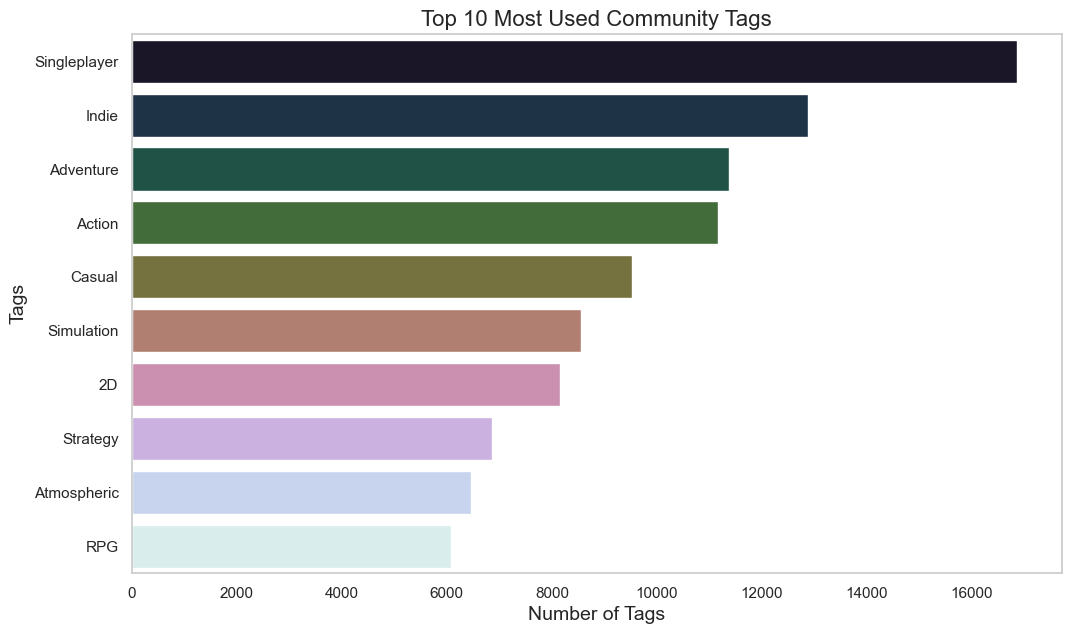

In [40]:
plt.figure()
top_tags = df['Tags'].dropna().str.split(',').explode().value_counts().head(10)
sns.barplot(y=top_tags.index, x=top_tags.values, palette='cubehelix',hue=top_tags.index)
plt.title('Top 10 Most Used Community Tags')
plt.grid(False)
plt.xlabel('Number of Tags')
plt.show()

# Which genres generate the most total revenue?

>## While "Indie" has the highest game count, "Action" and "RPG" dominate actual revenue. This proves that RPG players are willing to spend more money per game.



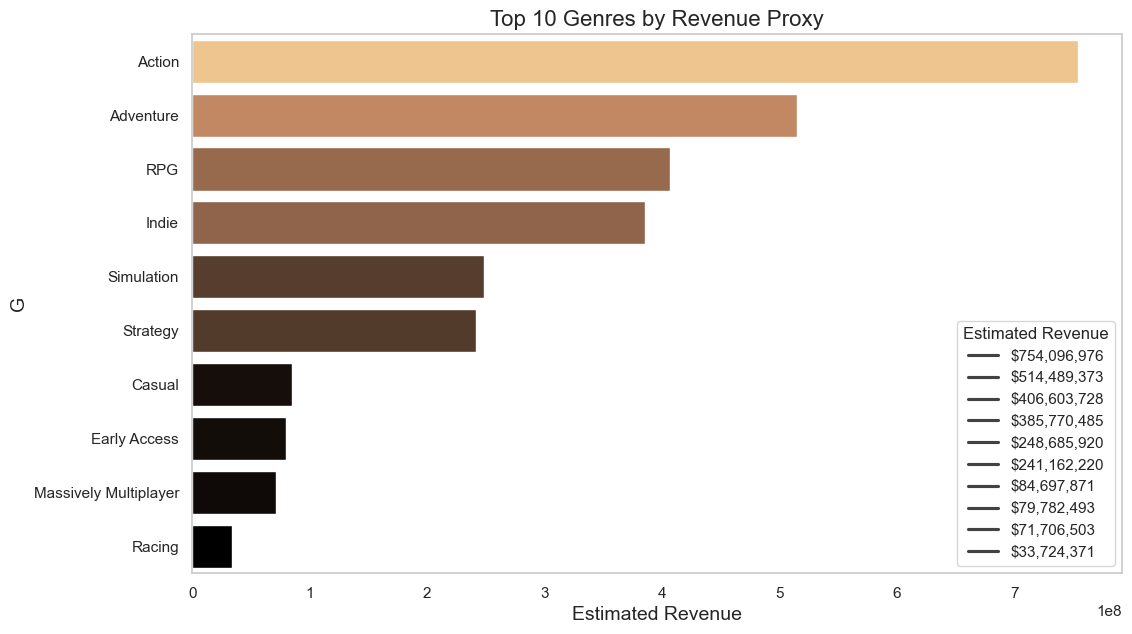

In [41]:
plt.figure()
genre_rev = df.assign(G=df['Genres'].str.split(',')).explode('G').groupby('G')['Rev_Proxy'].sum().sort_values(ascending=False).head(10)
sns.barplot(y=genre_rev.index, x=genre_rev.values, palette='copper',hue=genre_rev.values)
plt.title('Top 10 Genres by Revenue Proxy')
plt.grid(False)
plt.legend(title='Estimated Revenue', loc='lower right', labels=[f'${int(val):,}' for val in genre_rev.values])
plt.xlabel('Estimated Revenue')
plt.show()

# How does the "Early Access" tag affect a game's positivity?

>## Early Access games often enjoy slightly higher positivity. Players are more forgiving of bugs when a game is labeled as a "work in progress."

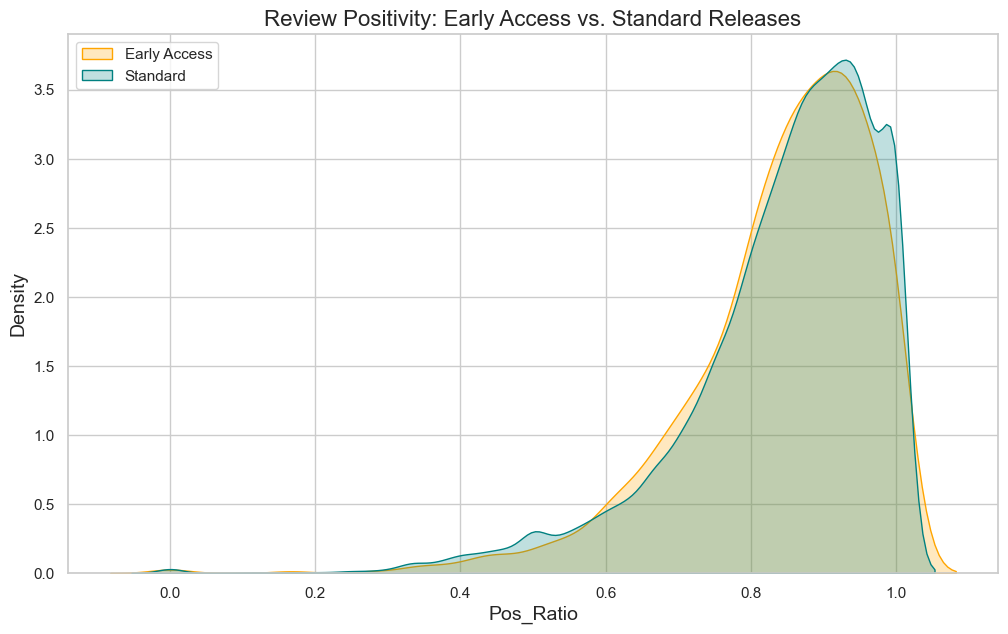

In [42]:
df['Is_EA'] = df['Tags'].fillna('').str.contains('Early Access').astype(int)
plt.figure()
sns.kdeplot(data=df[df['Is_EA']==1], x='Pos_Ratio', label='Early Access', fill=True, color='orange')
sns.kdeplot(data=df[df['Is_EA']==0], x='Pos_Ratio', label='Standard', fill=True, color='teal')
plt.title('Review Positivity: Early Access vs. Standard Releases')
plt.legend()
plt.show()

# Do Multiplayer games command a higher price than Singleplayer?

>## Yes. The inclusion of multiplayer servers and social features allows developers to successfully charge a higher premium.

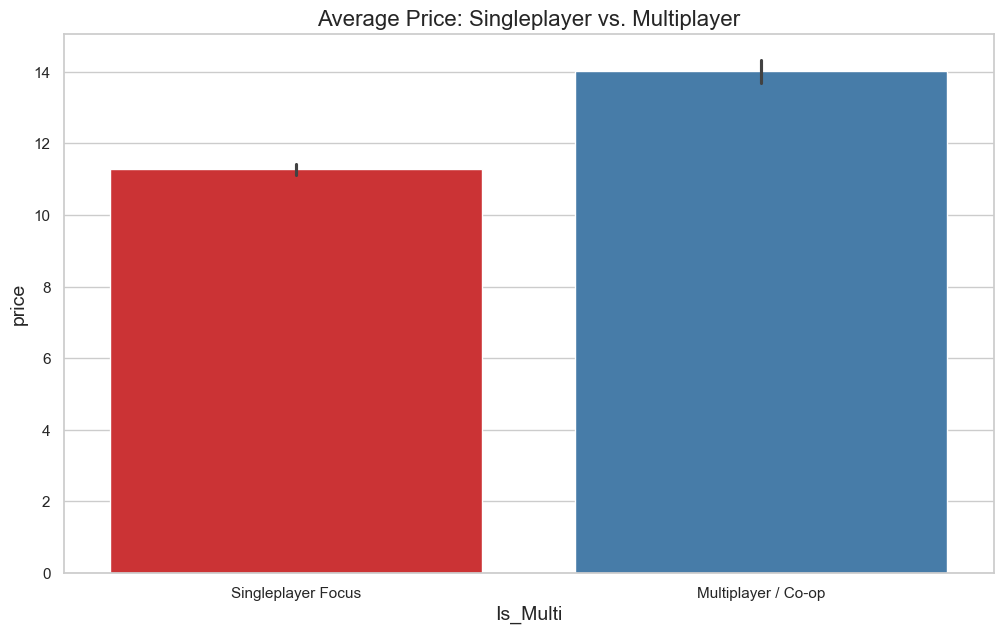

In [43]:
df['Is_Multi'] = df['Tags'].fillna('').str.contains('Multiplayer|Co-op', case=False).astype(int)
plt.figure()
sns.barplot(data=df, x='Is_Multi', y='price', palette='Set1',hue='Is_Multi',legend=False)
plt.xticks([0, 1], ['Singleplayer Focus', 'Multiplayer / Co-op'])
plt.title('Average Price: Singleplayer vs. Multiplayer')
plt.show()

# Who are the top 10 publishers by pure volume of games?

>## Big publishers like Paradox Interactive, CAPCOM, EA, Ubisoft, and SEGA have massive Steam libraries, showing their long-term commitment to the platform and diverse portfolios. But having a lot of games doesn’t always mean higher revenue or better player ratings.

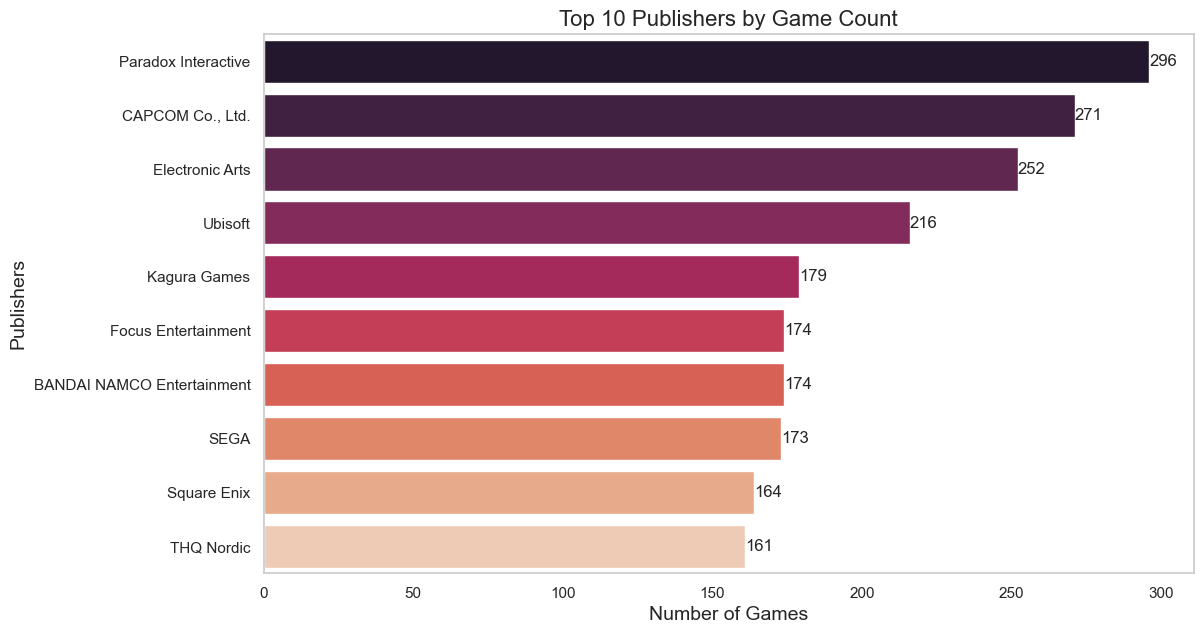

In [44]:
plt.figure()
top_pubs = (df[df['Publishers'] != 'Unknown']['Publishers'].value_counts().head(10))
ax = sns.barplot( y=top_pubs.index,x=top_pubs.values,palette='rocket',hue=top_pubs.index,legend=False)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Top 10 Publishers by Game Count')
plt.grid(False)
plt.xlabel('Number of Games')
plt.show()

# Who are the top 10 publishers by estimated revenue?

>## A completely different list from Plot 19. This proves that on Steam, Quality + Brand Reputation strictly beats Quantity.

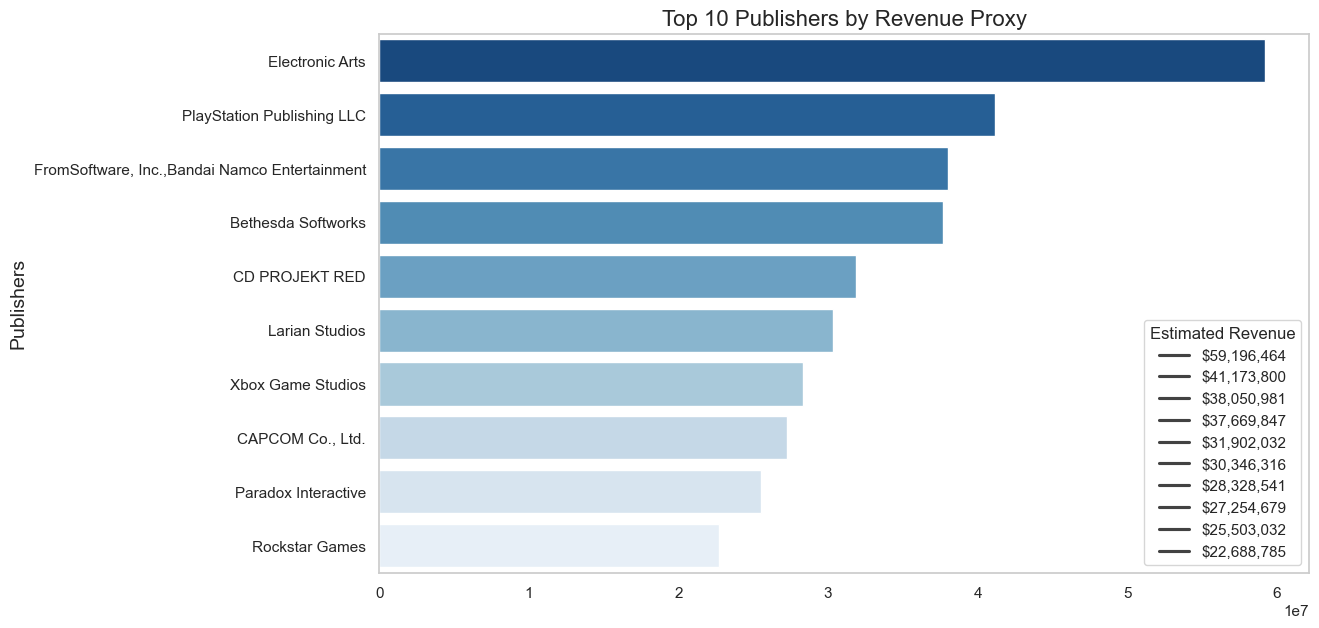

In [45]:
plt.figure()
pub_rev = df.groupby('Publishers')['Rev_Proxy'].sum().sort_values(ascending=False).head(10)
sns.barplot(y=pub_rev.index, x=pub_rev.values, palette='Blues_r',hue=pub_rev.index)
plt.title('Top 10 Publishers by Revenue Proxy')
plt.grid(False)
plt.legend(title='Estimated Revenue', loc='lower right', labels=[f'${int(val):,}' for val in pub_rev.values])
plt.show()

# What is the density of review scores for the Top 5 Developers?

>## Even top developers have their share of flops. The violin plots show that some studios consistently land in the ‘Very Positive’ range, while others swing between extremes—delivering both masterpieces and disasters.”

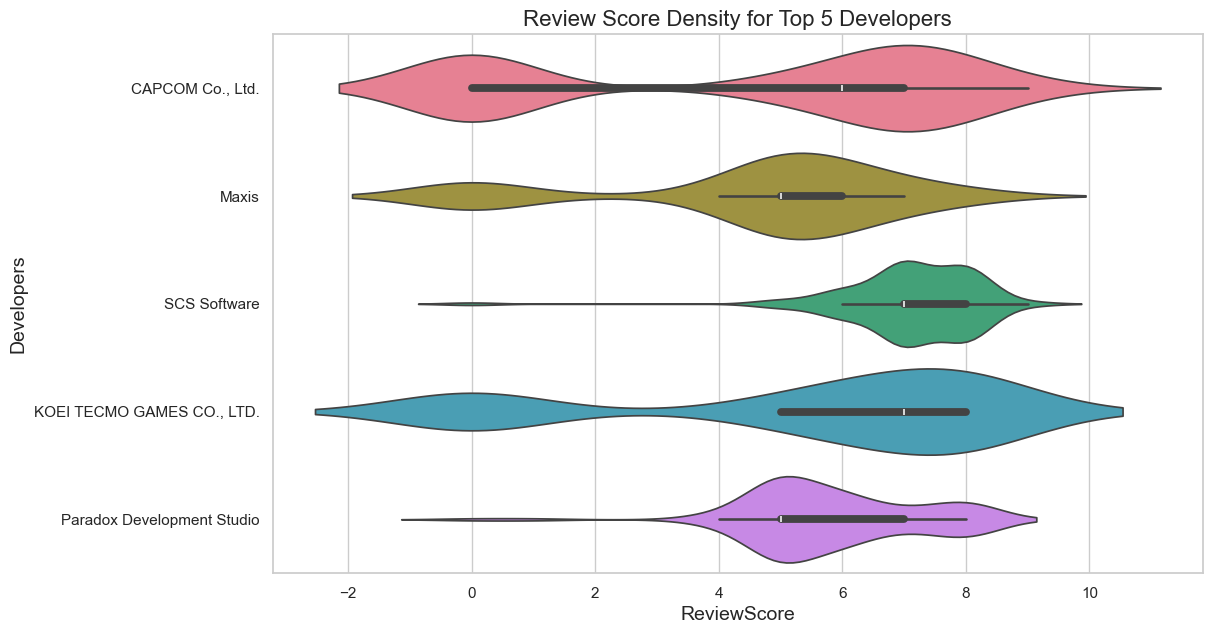

In [46]:
plt.figure()
top_5_devs = df['Developers'].value_counts().head(5).index
sns.violinplot(data=df[df['Developers'].isin(top_5_devs)], y='Developers', x='ReviewScore', palette='husl',hue='Developers')
plt.title('Review Score Density for Top 5 Developers')
plt.show()

# What proportion of the store is Self-Published?

>## Steam has essentially become an indie platform. Most of the games released there don’t have backing from big publishers, which means the vast majority are self-published by small studios or solo developers.

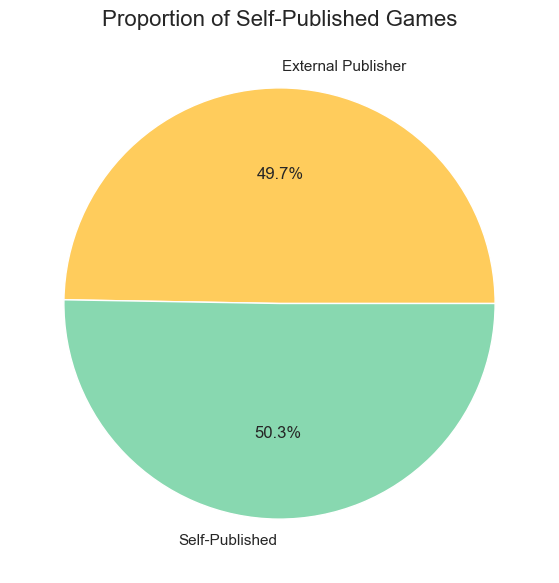

In [47]:
plt.figure()
df['Is_Indie'] = np.where(df['Publishers'].fillna('').str.lower().eq(df['Developers'].fillna('').str.lower()) | df['Publishers'].fillna('').str.contains('self-published', case=False, na=False),'Self-Published','External Publisher')
indie_counts = df['Is_Indie'].value_counts().reindex(['External Publisher', 'Self-Published'], fill_value=0)
plt.pie(indie_counts, labels=indie_counts.index, autopct='%1.1f%%', colors=['#ffcc5c', '#88d8b0'])
plt.title('Proportion of Self-Published Games')
plt.show()


# What is the correlation between all numerical features?

>## The ultimate summary map. Price correlates strongly with RAM requirements (bigger games cost more to make and buy), and Reviews correlate with Revenue Proxy.

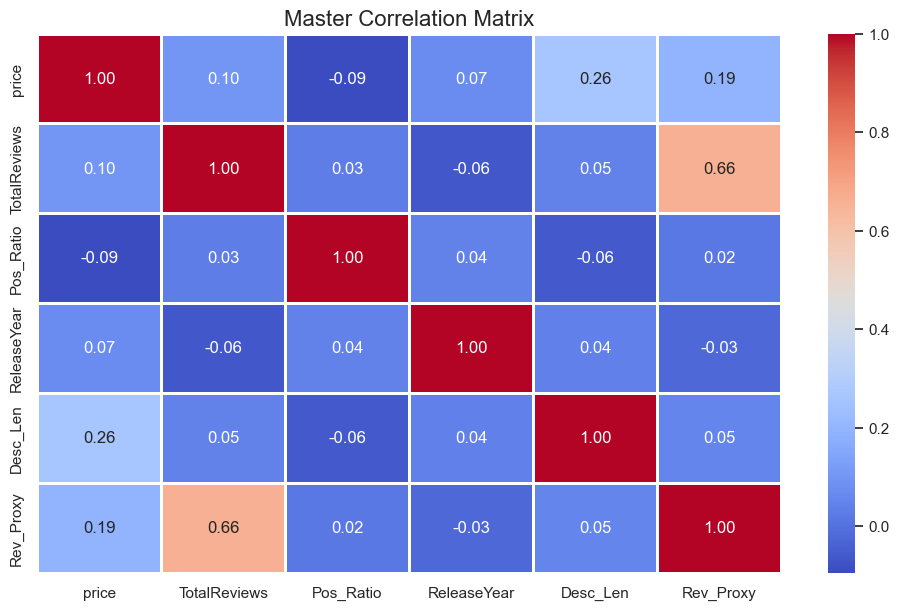

In [48]:
plt.figure()
if 'Desc_Len' not in df.columns:
    if 'Description' in df.columns:
        df['Desc_Len'] = df['Description'].fillna('').str.len()
    else:
        df['Desc_Len'] = 0
num_cols = ['price', 'TotalReviews', 'Pos_Ratio', 'ReleaseYear', 'Desc_Len', 'Rev_Proxy']
available = [c for c in num_cols if c in df.columns]
if len(available) < 2:
    print('Not enough numeric columns available for correlation heatmap. Available:', available)
else:
    sns.heatmap(df[available].dropna().corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)
    plt.title('Master Correlation Matrix')
    plt.show()


# How have minimum RAM requirements evolved over the last decade?

>## PC gaming hardware requirements are moving on a strict upward trajectory. This chart visualizes the exact timeline of when the industry standard shifted from a 2GB baseline in 2010, crossed the 4GB threshold around 2015, and steadily climbed to an average minimum requirement of 7GB by 2024. If a developer is building a game today, the data proves that optimizing for older 4GB systems is a waste of resources, as the modern baseline requirement has already reached the 7GB mark.

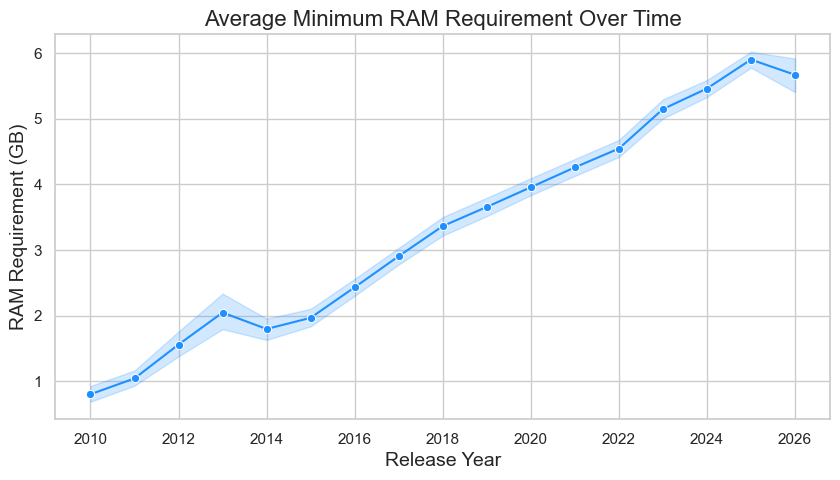

In [49]:
def get_ram(x):
    if pd.isna(x):
        return np.nan
    text = str(x).lower()
    nums = re.findall(r'\d+\.?\d*', text)
    if len(nums) == 0:
        return np.nan
    ram = float(nums[0])
    if 'mb' in text:
        ram = ram / 1024
    if ram > 128:
        return np.nan
    return ram
df['RAM_GB'] = df['MemoryRequirement'].apply(get_ram)

plt.figure(figsize=(10, 5))
sns.lineplot(data=df[df['ReleaseYear'] >= 2010],x='ReleaseYear',y='RAM_GB',color='dodgerblue',marker='o')
plt.title('Average Minimum RAM Requirement Over Time')
plt.xlabel('Release Year')
plt.ylabel('RAM Requirement (GB)')
plt.xticks(range(2010, 2027, 2))
plt.show()

# 📊 Key Findings & Conclusions

## 1. Market Saturation & Pricing Dynamics
- **Winner‑Takes‑All Reality**: A handful of viral hits capture nearly all player attention and reviews, leaving most titles overlooked.  
- **Crowded Low‑Price Tier**: The majority of games are priced under $10. Breaking into the $20+ premium tier requires strong marketing or an established IP.  
- **Revenue Concentration**: While cheap indie games dominate in volume, most revenue comes from titles priced between **$30–$60**.  

---

## 2. Player Sentiment & Reviews
- **Premium Punishment**: At the $60 AAA tier, players are far less forgiving—bugs or issues lead to harsher reviews.  
- **Free vs. Paid**: Paid games generally score higher. Free‑to‑Play titles are vulnerable to review bombing since anyone can leave feedback instantly.  
- **Early Access Forgiveness**: Players cut developers some slack when a game is labeled *Early Access*, tolerating bugs if they know it’s still in progress.  

---

## 3. Genre & Mechanics Insights
- **Saturated vs. Lucrative**: *Action*, *Indie*, and *Adventure* are the most crowded genres. But *Action* and *RPG* dominate revenue, showing RPG fans spend more per game.  
- **Singleplayer Demand**: Despite esports hype, *Singleplayer* remains the most common tag, proving strong demand for solo play.  
- **Multiplayer Premium**: Adding multiplayer or co‑op servers allows studios to charge higher baseline prices.  

---

## 4. Temporal & Release Trends
- **No Weekend Rule**: Developers avoid weekends. **Tuesday and Thursday** dominate launches to align with press cycles and Steam’s algorithm.  
- **Holiday Congestion**: October and November are packed with AAA releases ahead of the Steam Winter Sale.  
- **Hardware Evolution**: Minimum RAM requirements have steadily climbed—from 2GB (2010) → 4GB (2015) → ~7GB (2024).  

---

# 💡 Strategic Business Recommendations

## 1. Optimize Release Timing
- Avoid October–November if you’re indie or mid‑sized.  
- Launch in **Q1 or Q2** for better visibility.  
- Always pick **Tuesday or Thursday** for maximum press and algorithm traction.  

## 2. Target the Golden Revenue Formula
- Aim for the **$30–$60 tier**.  
- Blend **Action + RPG mechanics** with **Multiplayer/Co‑op** to justify premium pricing and maximize returns.  

## 3. Set Modern Hardware Baselines
- Stop optimizing for outdated 4GB RAM machines.  
- Design with **8GB RAM** as the minimum baseline—it matches today’s PC market reality.  

## 4. Use Early Access Wisely
- If QA resources are limited, launch in **Early Access**.  
- This shields your rating while players expect ongoing fixes and updates.  

## 5. Quality & Brand > Quantity
- Flooding the market with shovelware doesn’t equal success.  
- Focus on **polished games** and building a **strong brand reputation**—that’s what drives revenue and long‑term trust.  
